# 0) Portada y objetivos

# **Práctica: Paralelismo clásico y paralelismo cuántico**

**Asignatura:** Computación de Alto Rendimiento (Grado en IA)  
**Duración estimada:** 2 horas  
**Entorno:** Google Colab + Python + Qiskit (simulación local con AerSimulator)

## Objetivos de aprendizaje
- Entender qué significa paralelismo en HPC clásico (CPU, muchos procesos, speedup).
- Diferenciar ese paralelismo clásico del "paralelismo cuántico".
- Ver, con simulación, cómo la superposición permite procesar amplitudes de muchos estados a la vez.
- Comprender por qué la medición limita la información que se puede extraer.
- Implementar y ejecutar un ejemplo de interferencia útil: algoritmo de Deutsch (1 bit).
- Conectar ideas cuánticas con la mentalidad de HPC: rendimiento, límites y diseño del algoritmo.

## ¿Qué entendemos por "paralelismo" en HPC?
En HPC clásico, paralelismo suele significar:
- repartir trabajo entre **núcleos CPU**,
- usar **GPU** para miles de hilos,
- o distribuir tareas en un **cluster**.

El objetivo típico: reducir tiempo total y/o aumentar throughput.

## Qué **NO** es el paralelismo cuántico
No significa: "meto todas las entradas y al medir obtengo todas las respuestas".

Eso es un mito. En cuántica:
- puedes evolucionar una superposición de muchos estados,
- pero una medición devuelve un resultado (muestra),
- y la ventaja depende de diseñar **interferencia** para extraer una propiedad útil.


# 1) Setup (instalación y comprobación)


En esta sección:
1. Instalamos dependencias (`qiskit`, `qiskit-aer`).
2. Importamos librerías.
3. Fijamos semilla para reproducibilidad.
4. Verificamos que `AerSimulator` funciona correctamente.


In [ ]:
# Instalación (Colab): ejecutar una vez
# Si ya está instalado, no pasa nada.
%pip -q install qiskit qiskit-aer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.5 MB/s eta 0:00:00


In [ ]:
import time
import random
import multiprocessing as mp

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import qiskit
import qiskit_aer

# Semilla global para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Python listo.")
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("CPUs detectadas:", mp.cpu_count())


Python listo.
qiskit: 2.3.0
qiskit-aer: 0.17.2
CPUs detectadas: 2


In [ ]:
# Comprobación rápida de AerSimulator
sim = AerSimulator(seed_simulator=SEED)

qc_test = QuantumCircuit(1, 1)
qc_test.h(0)
qc_test.measure(0, 0)

compiled = transpile(qc_test, sim)
result = sim.run(compiled, shots=200, seed_simulator=SEED).result()
counts = result.get_counts()

print("Counts de prueba:", counts)
assert sum(counts.values()) == 200
print("AerSimulator funciona correctamente.")


Counts de prueba: {'1': 95, '0': 105}
AerSimulator funciona correctamente.


# 2) Recordatorio HPC: paralelismo clásico en CPU

Vamos a resolver un problema muy simple:

f(x) = x^2

para x = 0, 1, 2, …, N-1

Implementaremos:
- versión secuencial,
- versión paralela con `multiprocessing.Pool`.

Luego medimos tiempos y calculamos speedup aproximado.

> Nota didáctica: este problema es muy simple, así que el overhead de paralelizar puede ser importante.


In [ ]:
# Funciones del experimento clásico

def square(x):
    return x * x


def run_sequential(N):
    t0 = time.perf_counter()
    out = [square(x) for x in range(N)]
    t1 = time.perf_counter()
    return out, (t1 - t0)


def run_parallel_pool(N, n_processes, chunksize=10_000):
    t0 = time.perf_counter()
    with mp.Pool(processes=n_processes) as pool:
        out = pool.map(square, range(N), chunksize=chunksize)
    t1 = time.perf_counter()
    return out, (t1 - t0)


In [ ]:
# Benchmark simple
N = 1000000 # cámbialo para experimentar
n_processes = 8

seq_out, t_seq = run_sequential(N)
par_out, t_par = run_parallel_pool(N, n_processes=n_processes, chunksize=20_000)

# Comprobación de corrección
assert seq_out[:20] == par_out[:20]
assert seq_out[-20:] == par_out[-20:]

speedup = t_seq / t_par if t_par > 0 else np.nan
efficiency = speedup / n_processes if n_processes > 0 else np.nan

summary = pd.DataFrame({
    "Método": ["Secuencial", f"Pool ({n_processes} procesos)"],
    "Tiempo (s)": [t_seq, t_par],
})

print(f"N = {N:,}")
display(summary)
print(f"Speedup aproximado: {speedup:.3f}x")
print(f"Eficiencia aproximada: {efficiency:.3f}")


N = 1,000,000


,Método,Tiempo (s)
0,Secuencial,0.264771
1,Pool (8 procesos),0.955545


Speedup aproximado: 0.277x
Eficiencia aproximada: 0.035


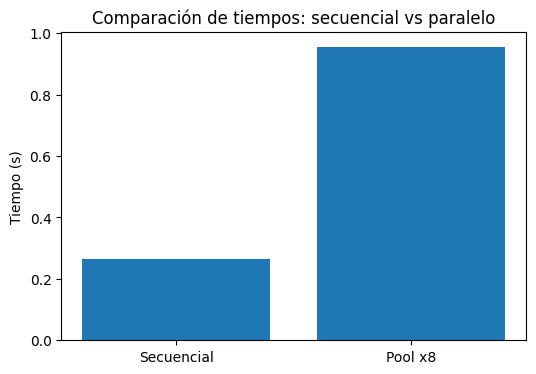

In [ ]:
# Visualización rápida de tiempos
labels = ["Secuencial", f"Pool x{n_processes}"]
values = [t_seq, t_par]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.ylabel("Tiempo (s)")
plt.title("Comparación de tiempos: secuencial vs paralelo")
plt.show()


### Comentario HPC (muy breve)
- Si el trabajo por elemento es pequeño, el overhead de crear procesos y mover datos puede dominar.
- El speedup real raramente es lineal: lo limita la parte secuencial (idea de Amdahl) y el overhead.
- En HPC de verdad, también importan cache, memoria, ancho de banda, afinidad de hilos, etc.

### Preguntas cortas para ti
1. ¿Qué pasa con el speedup cuando `N` es pequeño (por ejemplo, `N=50_000`)?
2. ¿Qué pasa si subes `n_processes` por encima de los núcleos físicos?
3. ¿Qué variable cambiarías para reducir overhead de `Pool.map`?


# 3) Puente conceptual: del paralelismo clásico al cuántico

## Bits vs qubits
- Un bit clásico está en `0` o `1`.
- Un qubit puede estar en superposición: |ϕ⟩ = α|0⟩ + β|1⟩.

Con `n` qubits, el estado tiene amplitudes para 2ⁿ bases computacionales.

## "Paralelismo cuántico" (idea)
Si aplicamos una operación cuántica a un estado en superposición,
la evolución afecta simultáneamente las amplitudes de muchos estados base.

## Pero cuidado con la medición
Al medir, no obtenemos la tabla completa de resultados:
obtenemos una muestra (un resultado por shot).

La ventaja cuántica no viene de "leer todo", sino de diseñar interferencia para que
la propiedad que nos interesa aparezca con alta probabilidad.


# 4) Experimento 1: Superposición con Hadamards

Vamos a crear un circuito muy básico:
1. Partimos de ψ = |0 … 0⟩.
2. Aplicamos Hadamard a todos los qubits.
3. Medimos.

Esperamos una distribución aproximadamente uniforme entre los (2^n) estados.


In [ ]:
def run_hadamard_experiment(n, shots, seed=SEED):
    qc = QuantumCircuit(n, n)
    for q in range(n):
        qc.h(q)
    qc.measure(range(n), range(n))

    sim_local = AerSimulator(seed_simulator=seed)
    tqc = transpile(qc, sim_local)
    result = sim_local.run(tqc, shots=shots, seed_simulator=seed).result()
    counts = result.get_counts()
    return qc, counts


def counts_to_df(counts, shots):
    rows = []
    for state, c in sorted(counts.items()):
        rows.append({"estado": state, "counts": c, "prob_emp": c / shots})
    return pd.DataFrame(rows)


def plot_counts(counts, title):
    states = sorted(counts.keys())
    vals = [counts[s] for s in states]
    plt.figure(figsize=(8, 3.8))
    plt.bar(states, vals)
    plt.title(title)
    plt.xlabel("Estado medido (bitstring)")
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


n=3, shots=50, estados posibles teóricos=8
estados observados en la muestra=8


,estado,counts,prob_emp
0,000,3,0.06
1,001,6,0.12
2,010,11,0.22
3,011,2,0.04
4,100,12,0.24
5,101,6,0.12
6,110,1,0.02
7,111,9,0.18


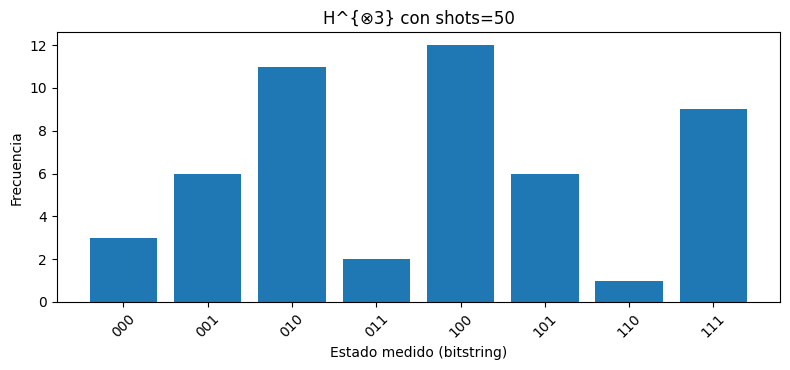

Prob. media empírica por estado: 0.1250
Prob. teórica por estado:       0.1250
n=3, shots=100, estados posibles teóricos=8
estados observados en la muestra=8


,estado,counts,prob_emp
0,000,13,0.13
1,001,16,0.16
2,010,19,0.19
3,011,8,0.08
4,100,16,0.16
5,101,9,0.09
6,110,6,0.06
7,111,13,0.13


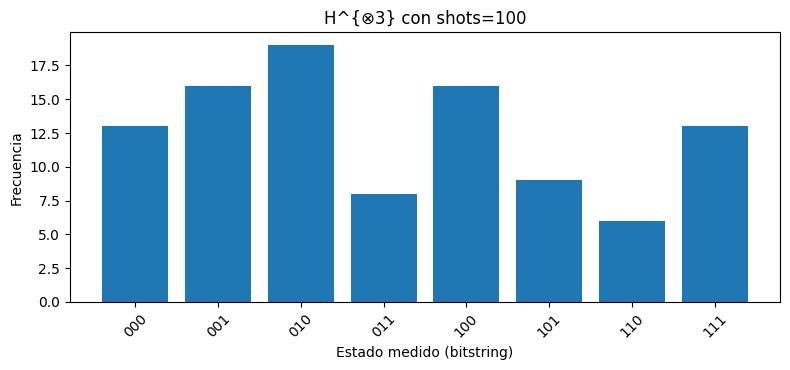

Prob. media empírica por estado: 0.1250
Prob. teórica por estado:       0.1250
n=4, shots=50, estados posibles teóricos=16
estados observados en la muestra=13


,estado,counts,prob_emp
0,0000,2,0.04
1,0001,7,0.14
2,0010,4,0.08
3,0011,2,0.04
4,0100,2,0.04
5,0101,7,0.14
6,0111,2,0.04
7,1000,4,0.08
8,1001,6,0.12
9,1010,2,0.04


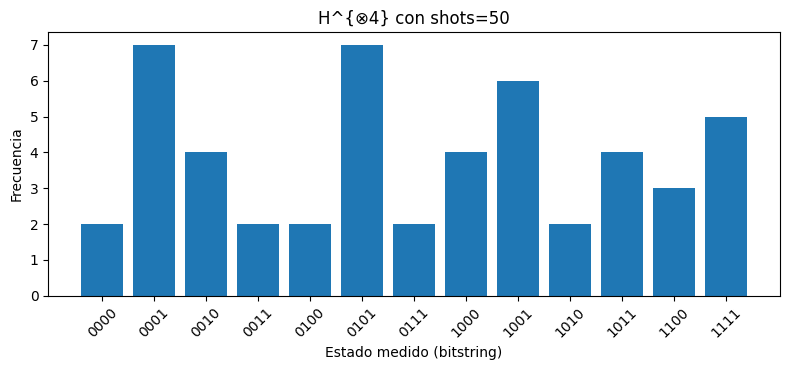

Prob. media empírica por estado: 0.0769
Prob. teórica por estado:       0.0625
n=4, shots=100, estados posibles teóricos=16
estados observados en la muestra=16


,estado,counts,prob_emp
0,0000,8,0.08
1,0001,8,0.08
2,0010,8,0.08
3,0011,5,0.05
4,0100,7,0.07
5,0101,8,0.08
6,0110,4,0.04
7,0111,7,0.07
8,1000,9,0.09
9,1001,9,0.09


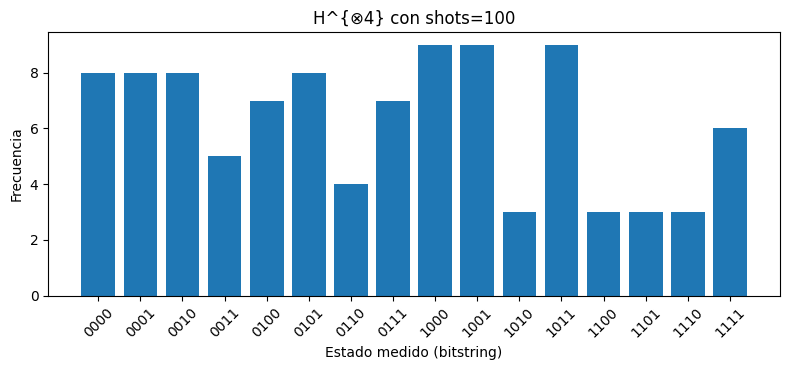

Prob. media empírica por estado: 0.0625
Prob. teórica por estado:       0.0625


In [ ]:
# Ejecutamos para n=3 y n=4, con shots 50 y 100
for n in [3, 4]:
    for shots in [50, 100]:
        qc, counts = run_hadamard_experiment(n=n, shots=shots)
        df_counts = counts_to_df(counts, shots)

        print("=" * 70)
        print(f"n={n}, shots={shots}, estados posibles teóricos={2**n}")
        print(f"estados observados en la muestra={len(counts)}")
        display(df_counts.head(16))

        plot_counts(counts, title=f"H^{{⊗{n}}} con shots={shots}")

        # Comprobación simple: probabilidad media por estado ~ 1/2^n
        p_mean_emp = df_counts["prob_emp"].mean()
        p_mean_theo = 1 / (2**n)
        print(f"Prob. media empírica por estado: {p_mean_emp:.4f}")
        print(f"Prob. teórica por estado:       {p_mean_theo:.4f}")


### Interpretación
- Al aplicar `H` a todos los qubits, generamos superposición uniforme.
- Con más shots, la distribución observada se parece más a la uniforme ideal.
- Número de estados posibles crece como \(2^n\).

### Ejercicio guiado rápido
1. Cambia `n` a 5.
2. Ejecuta con `shots=1000` y `shots=10000`.
3. Responde: ¿por qué no "vemos" todos los estados en una sola medición?


# 5) Experimento 2: "Evaluar una función sobre todas las entradas" (oracle simple)

Queremos implementar un `oracle` para:


f(x_0, x_1) = x_0 ⊕ x_1


Usaremos 3 qubits:
- `q0, q1`: entrada `x` (en superposición).
- `q2`: ancilla para almacenar la salida de la función (modo XOR reversible).

Construcción del oracle reversible:

|x_0, x_1, y⟩ ↦ |x_0, x_1, y ⊕ f(x_0,x_1)⟩

Para `f=x0 XOR x1`, basta aplicar dos CNOT al ancilla.


In [ ]:
def xor_oracle_circuit(shots=4000, seed=SEED):
    qc = QuantumCircuit(3, 3)

    # 1) Superposición en qubits de entrada
    qc.h(0)
    qc.h(1)

    # 2) Oracle f(x0,x1)=x0 XOR x1 almacenado en ancilla q2
    qc.cx(0, 2)
    qc.cx(1, 2)

    # 3) Medición
    qc.measure([0, 1, 2], [0, 1, 2])

    sim_local = AerSimulator(seed_simulator=seed)
    tqc = transpile(qc, sim_local)
    result = sim_local.run(tqc, shots=shots, seed_simulator=seed).result()
    counts = result.get_counts()
    return qc, counts


def decode_xor_counts(counts, shots):
    rows = []
    for bits, c in sorted(counts.items()):
        # Qiskit devuelve bitstring como c2c1c0
        q2 = int(bits[0])
        q1 = int(bits[1])
        q0 = int(bits[2])
        fx = q0 ^ q1
        rows.append({
            "bits(c2c1c0)": bits,
            "x0": q0,
            "x1": q1,
            "ancilla(q2)": q2,
            "x0_xor_x1": fx,
            "coincide": int(q2 == fx),
            "counts": c,
            "prob_emp": c / shots,
        })
    return pd.DataFrame(rows)


     ┌───┐          ┌─┐      
q_0: ┤ H ├──■───────┤M├──────
     ├───┤  │       └╥┘┌─┐   
q_1: ┤ H ├──┼────■───╫─┤M├───
     └───┘┌─┴─┐┌─┴─┐ ║ └╥┘┌─┐
q_2: ─────┤ X ├┤ X ├─╫──╫─┤M├
          └───┘└───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     0  1  2 


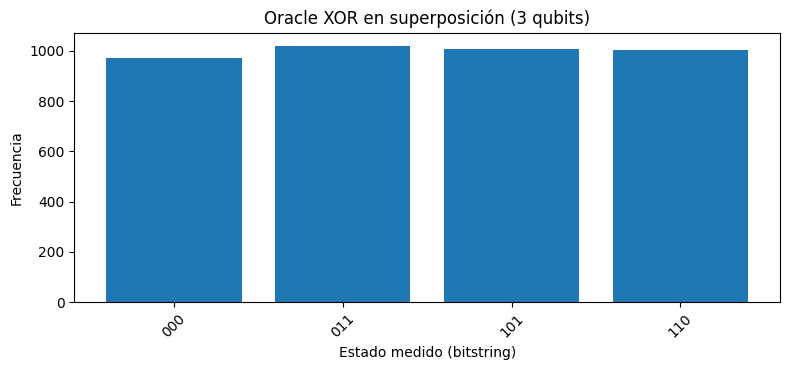

,bits(c2c1c0),x0,x1,ancilla(q2),x0_xor_x1,coincide,counts,prob_emp
0,000,0,0,0,0,1,970,0.24250
1,011,1,1,0,0,1,1021,0.25525
2,101,1,0,1,1,1,1007,0.25175
3,110,0,1,1,1,1,1002,0.25050


Comprobación OK: ancilla coincide con x0 XOR x1 en los estados observados.


In [ ]:
qc_xor, counts_xor = xor_oracle_circuit(shots=4000)
print(qc_xor.draw("text"))

plot_counts(counts_xor, "Oracle XOR en superposición (3 qubits)")

df_xor = decode_xor_counts(counts_xor, shots=4000)
display(df_xor)

# Comprobación: en este circuito ideal, toda fila observada debe cumplir ancilla = x0 XOR x1
assert df_xor["coincide"].min() == 1
print("Comprobación OK: ancilla coincide con x0 XOR x1 en los estados observados.")


### ¿Qué hemos demostrado aquí?
- Aplicamos `U_f` sobre una entrada en superposición.
- Eso significa que la operación actúa sobre amplitudes de todas las entradas a la vez.
- Pero no podemos leer "toda la tabla" en una sola medición.

**Mensaje clave:** paralelismo cuántico por sí solo no basta; hace falta interferencia útil.


# 6) Punto clave: limitación por medida

## Comparación clara HPC vs cuántica

### HPC clásico
- Si paralelizas en CPU/GPU/cluster, puedes calcular muchas salidas y guardarlas todas.
- En principio, puedes leer todo el vector de resultados (si tienes memoria/tiempo I/O).

### Cuántica
- Evolucionas amplitudes de muchos estados simultáneamente.
- Pero medir devuelve un resultado por shot.
- La ventaja aparece cuando el algoritmo usa **interferencia** para concentrar probabilidad en la información global que interesa.

En otras palabras: en cuántica no optimizamos "leer todas las respuestas", sino "extraer una propiedad global".


# 7) Experimento 3: Interferencia con el algoritmo de Deutsch (1-bit)

Problema de Deutsch (versión básica):

a) Tenemos una función \(f:\{0,1\} → \{0,1\}\).  
b) Queremos saber si es **constante** o **balanceada**.

Posibles funciones (4):
- Constante 0: \(f(0)=0, f(1)=0\)
- Constante 1: \(f(0)=1, f(1)=1\)
- Identidad: \(f(0)=0, f(1)=1\) (balanceada)
- NOT: \(f(0)=1, f(1)=0\) (balanceada)

Deutsch usa interferencia para clasificar en 1 evaluación del oracle (ideal).


In [ ]:
def apply_deutsch_oracle(qc, oracle_name, x_qubit=0, y_qubit=1):
    # Aplica U_f para cuatro oracles posibles.
    if oracle_name == "const_0":
        # f(x)=0 -> y = y xor 0 (no hace nada)
        pass
    elif oracle_name == "const_1":
        # f(x)=1 -> y = y xor 1
        qc.x(y_qubit)
    elif oracle_name == "identity":
        # f(x)=x
        qc.cx(x_qubit, y_qubit)
    elif oracle_name == "not":
        # f(x)=1-x -> y = y xor (1-x) = y xor 1 xor x
        qc.x(y_qubit)
        qc.cx(x_qubit, y_qubit)
    else:
        raise ValueError("oracle_name no reconocido")


def build_deutsch_circuit(oracle_name):
    qc = QuantumCircuit(2, 1)

    # Estado inicial |0>|1>
    qc.x(1)

    # Hadamard en ambos
    qc.h(0)
    qc.h(1)

    # Oracle
    apply_deutsch_oracle(qc, oracle_name, 0, 1)

    # Interferencia en qubit de consulta
    qc.h(0)

    # Medimos solo qubit x
    qc.measure(0, 0)
    return qc


def run_deutsch(oracle_name, shots=1024, seed=SEED):
    qc = build_deutsch_circuit(oracle_name)
    sim_local = AerSimulator(seed_simulator=seed)
    tqc = transpile(qc, sim_local)
    result = sim_local.run(tqc, shots=shots, seed_simulator=seed).result()
    counts = result.get_counts()

    # bit más frecuente en la medición del qubit de consulta
    pred_bit = max(counts, key=counts.get)
    pred_class = "constante" if pred_bit == "0" else "balanceada"
    return qc, counts, pred_bit, pred_class


In [ ]:
oracles_info = {
    "const_0": "constante",
    "const_1": "constante",
    "identity": "balanceada",
    "not": "balanceada",
}

rows = []
for name, expected in oracles_info.items():
    qc, counts, pred_bit, pred_class = run_deutsch(name, shots=1024)
    print("=" * 70)
    print(f"Oracle: {name}")
    print(qc.draw("text"))
    print("Counts:", counts)
    print(f"Clasificación predicha: {pred_class}")
    print(f"Clasificación esperada: {expected}")

    rows.append({
        "oracle": name,
        "esperada": expected,
        "predicha": pred_class,
        "counts": str(counts),
    })

results_deutsch = pd.DataFrame(rows)
display(results_deutsch)

# Comprobación automática
assert (results_deutsch["esperada"] == results_deutsch["predicha"]).all()
print("Todas las clasificaciones son correctas en simulación ideal.")


Oracle: const_0
     ┌───┐┌───┐┌─┐
q_0: ┤ H ├┤ H ├┤M├
     ├───┤├───┤└╥┘
q_1: ┤ X ├┤ H ├─╫─
     └───┘└───┘ ║ 
c: 1/═══════════╩═
                0 
Counts: {'0': 1024}
Clasificación predicha: constante
Clasificación esperada: constante
Oracle: const_1
     ┌───┐┌───┐     ┌─┐
q_0: ┤ H ├┤ H ├─────┤M├
     ├───┤├───┤┌───┐└╥┘
q_1: ┤ X ├┤ H ├┤ X ├─╫─
     └───┘└───┘└───┘ ║ 
c: 1/════════════════╩═
                     0 
Counts: {'0': 1024}
Clasificación predicha: constante
Clasificación esperada: constante
Oracle: identity
     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├──────╫─
     └───┘└───┘└───┘      ║ 
c: 1/═════════════════════╩═
                          0 
Counts: {'1': 1024}
Clasificación predicha: balanceada
Clasificación esperada: balanceada
Oracle: not
     ┌───┐               ┌───┐┌─┐
q_0: ┤ H ├────────────■──┤ H ├┤M├
     ├───┤┌───┐┌───┐┌─┴─┐└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├┤ X ├──────╫─
     └───┘└───┘└───┘└───┘      ║ 

,oracle,esperada,predicha,counts
0,const_0,constante,constante,{'0': 1024}
1,const_1,constante,constante,{'0': 1024}
2,identity,balanceada,balanceada,{'1': 1024}
3,not,balanceada,balanceada,{'1': 1024}


Todas las clasificaciones son correctas en simulación ideal.


### Conexión con la idea principal
Aquí sí aparece una ganancia conceptual: no intentamos recuperar toda la tabla de verdad.

En su lugar, usamos interferencia para extraer **una propiedad global** (constante vs balanceada).


# 8) Cierre y takeaways

- **Quantum parallelism** = superposición + aplicar `U_f` sobre muchos estados a la vez.
- **Medición** limita la información que se extrae en una ejecución.
- La ventaja cuántica viene de **interferencia** y de la estructura del problema.
- **HPC clásico vs cuántica**: paradigmas distintos; ambos son "alto rendimiento", pero no funcionan igual.


# 9) Bloque final de ejercicios

## Ejercicios obligatorios
1. **Doble Hadamard (obligatorio):**
   - Construye un circuito de 1 qubit con `H` seguido de `H` y mide.
   - Comprueba que vuelve a `|0>` (salvo fluctuación estadística si hay ruido).

2. **Shots y estabilidad (obligatorio):**
   - Repite el Experimento 1 con `n=4` y shots = 200, 1000, 10000.
   - ¿Cómo cambia la cercanía a la distribución uniforme?

3. **Oracle AND (obligatorio):**
   - Sustituye `f(x)=x0 XOR x1` por `f(x)=x0 AND x1`.
   - Pista: para 2 bits, puedes usar `CCX` (Toffoli) hacia el ancilla.
   - Verifica en la tabla de counts que el ancilla vale 1 solo cuando `x0=x1=1`.

4. **Deutsch para una función concreta (obligatorio):**
   - Elige `identity` o `not`.
   - Ejecuta y verifica que la salida clasifica como balanceada.
   - Explica en 2-3 líneas por qué basta con 1 consulta al oracle en el algoritmo.

